---
## Notebook 2: Implementación de Baselines en el Dataset de Noticias Falsas (WELFake)

**Nombre:** Zhang Tan Rubi

**Objetivo:**
- Cargar el dataset WELFake ya limpio del EDA
- Entrenar los 4 baselines (LogReg, SVM, Naive Bayes, Decision Tree)
- Evaluar y comparar con métricas y matrices de confusión


---
## 1. Carga del dataset limpio


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

df = pd.read_csv('/content/drive/MyDrive/ModeladoPredictivo2026/data/WELFake_limpio.csv')
df['title'] = df['title'].fillna('')
df['content'] = df['title'] + ' ' + df['text']

class_names = {0: 'Fake', 1: 'Real'}

print(f'Dataset cargado: {len(df):,} noticias')
print(f'Distribucion de clases:')
for label, count in df['label'].value_counts().sort_index().items():
    print(f'  {class_names[label]} (label={label}): {count:,}  ({count/len(df)*100:.1f}%)')

Dataset cargado: 63,110 noticias
Distribucion de clases:
  Fake (label=0): 34,790  (55.1%)
  Real (label=1): 28,320  (44.9%)


---
## 2. Representación TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF sobre el campo combinado (title + text)
tfidf = TfidfVectorizer(max_features=20000)
X = tfidf.fit_transform(df['content'])
y = df['label'].values

words = tfidf.get_feature_names_out()

print(f'Matriz TF-IDF: {X.shape[0]:,} documentos x {X.shape[1]:,} features')

Matriz TF-IDF: 63,110 documentos x 20,000 features


---
## 3. Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 30 runs con distintas semillas
acc_lr, prec_lr, rec_lr, f1_lr = [], [], [], []

for seed in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    lr = LogisticRegression(max_iter=1000, C=1.0)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    acc_lr.append(accuracy_score(y_test, y_pred))
    prec_lr.append(precision_score(y_test, y_pred, zero_division=0))
    rec_lr.append(recall_score(y_test, y_pred, zero_division=0))
    f1_lr.append(f1_score(y_test, y_pred, zero_division=0))

print('Regresión Logística')
print(f'Accuracy : {np.mean(acc_lr):.4f} +/- {np.std(acc_lr):.4f}')
print(f'Precision: {np.mean(prec_lr):.4f} +/- {np.std(prec_lr):.4f}')
print(f'Recall   : {np.mean(rec_lr):.4f} +/- {np.std(rec_lr):.4f}')
print(f'F1-Score : {np.mean(f1_lr):.4f} +/- {np.std(f1_lr):.4f}')

Regresión Logística
Accuracy : 0.9498 +/- 0.0020
Precision: 0.9461 +/- 0.0028
Recall   : 0.9419 +/- 0.0031
F1-Score : 0.9440 +/- 0.0023


=== Classification Report — Logistic Regression ===
              precision    recall  f1-score   support

        Fake       0.95      0.95      0.95      6958
        Real       0.94      0.94      0.94      5664

    accuracy                           0.95     12622
   macro avg       0.95      0.94      0.95     12622
weighted avg       0.95      0.95      0.95     12622



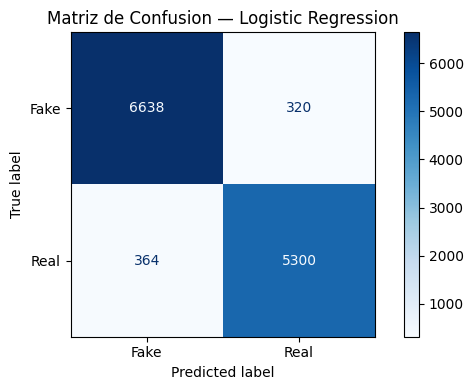


Top 10 palabras -> Fake (label=0):
  reuters              peso = -22.775
  said                 peso = -15.996
  breitbart            peso = -14.288
  follow               peso = -9.209
  on                   peso = -7.765
  2017                 peso = -5.949
  york                 peso = -5.652
  twitter              peso = -5.581
  but                  peso = -5.574
  mr                   peso = -4.952

Top 10 palabras -> Real (label=1):
  via                  peso = 17.599
  image                peso = 10.038
  featured             peso = 9.705
  video                peso = 9.202
  us                   peso = 7.678
  hillary              peso = 7.553
  getty                peso = 7.224
  com                  peso = 7.205
  october              peso = 6.875
  2016                 peso = 5.882


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analisis detallado con seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Classification Report — Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'Real']))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Fake', 'Real'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusion — Logistic Regression')
plt.tight_layout()
plt.show()

# Top 10 palabras mas indicativas de cada clase
coefs = lr.coef_[0]
top_fake = np.argsort(coefs)[:10]   # pesos mas negativos -> Fake (label=0)
top_real = np.argsort(coefs)[-10:][::-1]  # pesos mas positivos -> Real (label=1)

print('\nTop 10 palabras -> Fake (label=0):')
for i in top_fake:
    print(f'  {words[i]:<20} peso = {coefs[i]:.3f}')

print('\nTop 10 palabras -> Real (label=1):')
for i in top_real:
    print(f'  {words[i]:<20} peso = {coefs[i]:.3f}')

---
## 4. Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 30 runs con distintas semillas
acc_svm, prec_svm, rec_svm, f1_svm = [], [], [], []

for seed in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    svm = LinearSVC(max_iter=2000, C=1.0)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    acc_svm.append(accuracy_score(y_test, y_pred))
    prec_svm.append(precision_score(y_test, y_pred, zero_division=0))
    rec_svm.append(recall_score(y_test, y_pred, zero_division=0))
    f1_svm.append(f1_score(y_test, y_pred, zero_division=0))

print('Support Vector Machines (SVM)')
print(f'Accuracy : {np.mean(acc_svm):.4f} +/- {np.std(acc_svm):.4f}')
print(f'Precision: {np.mean(prec_svm):.4f} +/- {np.std(prec_svm):.4f}')
print(f'Recall   : {np.mean(rec_svm):.4f} +/- {np.std(rec_svm):.4f}')
print(f'F1-Score : {np.mean(f1_svm):.4f} +/- {np.std(f1_svm):.4f}')

Support Vector Machines (SVM)
Accuracy : 0.9609 +/- 0.0012
Precision: 0.9579 +/- 0.0016
Recall   : 0.9549 +/- 0.0022
F1-Score : 0.9564 +/- 0.0014


=== Classification Report — SVM LinearSVC ===
              precision    recall  f1-score   support

        Fake       0.96      0.96      0.96      6958
        Real       0.95      0.95      0.95      5664

    accuracy                           0.96     12622
   macro avg       0.96      0.96      0.96     12622
weighted avg       0.96      0.96      0.96     12622



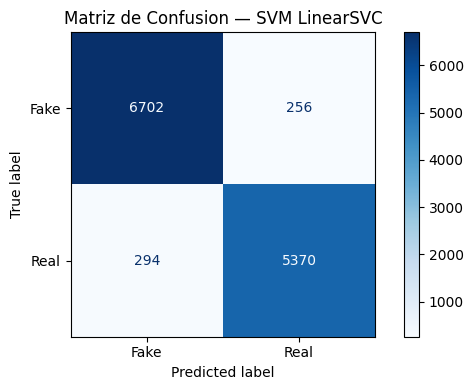


Top 10 palabras -> Fake (label=0):
  reuters              peso = -16.646
  breitbart            peso = -7.352
  follow               peso = -6.672
  said                 peso = -5.239
  2017                 peso = -3.977
  twitter              peso = -3.812
  york                 peso = -3.738
  but                  peso = -2.995
  jeromeehudson        peso = -2.965
  factbox              peso = -2.733

Top 10 palabras -> Real (label=1):
  via                  peso = 15.735
  featured             peso = 6.890
  getty                peso = 6.206
  image                peso = 5.545
  com                  peso = 4.835
  read                 peso = 4.774
  breaking             peso = 4.739
  october              peso = 4.708
  video                peso = 4.196
  co                   peso = 3.499


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analisis detallado con seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
svm = LinearSVC(max_iter=2000, C=1.0)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print('=== Classification Report — SVM LinearSVC ===')
print(classification_report(y_test, y_pred_svm, target_names=['Fake', 'Real']))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=['Fake', 'Real'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusion — SVM LinearSVC')
plt.tight_layout()
plt.show()

# Top 10 palabras mas indicativas de cada clase
coefs_svm = svm.coef_[0]
top_fake_svm = np.argsort(coefs_svm)[:10]
top_real_svm = np.argsort(coefs_svm)[-10:][::-1]

print('\nTop 10 palabras -> Fake (label=0):')
for i in top_fake_svm:
    print(f'  {words[i]:<20} peso = {coefs_svm[i]:.3f}')

print('\nTop 10 palabras -> Real (label=1):')
for i in top_real_svm:
    print(f'  {words[i]:<20} peso = {coefs_svm[i]:.3f}')

---
## 5. Clasificador Bayesiano (Naive Bayes)

In [ ]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 30 runs con distintas semillas
acc_nb, prec_nb, rec_nb, f1_nb = [], [], [], []

for seed in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    nb = ComplementNB(alpha=1.0)
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)

    acc_nb.append(accuracy_score(y_test, y_pred))
    prec_nb.append(precision_score(y_test, y_pred, zero_division=0))
    rec_nb.append(recall_score(y_test, y_pred, zero_division=0))
    f1_nb.append(f1_score(y_test, y_pred, zero_division=0))

print('Clasificador Bayesiano (Naive Bayes)')
print(f'Accuracy : {np.mean(acc_nb):.4f} +/- {np.std(acc_nb):.4f}')
print(f'Precision: {np.mean(prec_nb):.4f} +/- {np.std(prec_nb):.4f}')
print(f'Recall   : {np.mean(rec_nb):.4f} +/- {np.std(rec_nb):.4f}')
print(f'F1-Score : {np.mean(f1_nb):.4f} +/- {np.std(f1_nb):.4f}')

Clasificador Bayesiano (Naive Bayes)
Accuracy : 0.8600 +/- 0.0027
Precision: 0.8228 +/- 0.0031
Recall   : 0.8769 +/- 0.0044
F1-Score : 0.8490 +/- 0.0029


=== Classification Report — Naive Bayes ComplementNB ===
              precision    recall  f1-score   support

        Fake       0.89      0.84      0.86      6958
        Real       0.81      0.87      0.84      5664

    accuracy                           0.85     12622
   macro avg       0.85      0.85      0.85     12622
weighted avg       0.86      0.85      0.85     12622

Predicciones de ejemplo:
  [OK   ] Real=Real   Pred=Real   Conf=68%
  [OK   ] Real=Fake   Pred=Fake   Conf=99%
  [OK   ] Real=Fake   Pred=Fake   Conf=85%
  [OK   ] Real=Real   Pred=Real   Conf=95%
  [OK   ] Real=Fake   Pred=Fake   Conf=61%


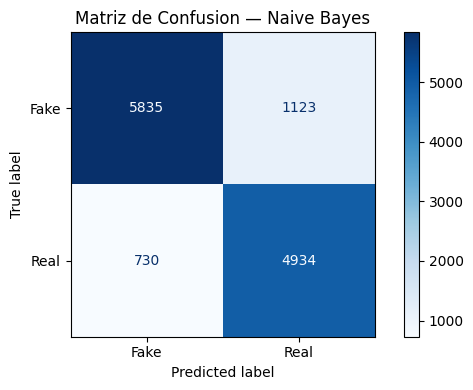

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analisis detallado con seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
nb = ComplementNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print('=== Classification Report — Naive Bayes ComplementNB ===')
print(classification_report(y_test, y_pred_nb, target_names=['Fake', 'Real']))

# Mostrar predicciones de ejemplo
print('Predicciones de ejemplo:')
proba = nb.predict_proba(X_test[:5])
for i in range(5):
    real = class_names[y_test[i]]
    pred = class_names[y_pred_nb[i]]
    conf = max(proba[i]) * 100
    ok = 'OK' if real == pred else 'ERROR'
    print(f'  [{ok:5}] Real={real:<6} Pred={pred:<6} Conf={conf:.0f}%')

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Fake', 'Real'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusion — Naive Bayes')
plt.tight_layout()
plt.show()

---
## 6. Arboles de Decision (Decision Tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# 30 runs con distintas semillas
acc_dt, prec_dt, rec_dt, f1_dt = [], [], [], []

for seed in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, max_features=1000, random_state=seed)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)

    acc_dt.append(accuracy_score(y_test, y_pred))
    prec_dt.append(precision_score(y_test, y_pred, zero_division=0))
    rec_dt.append(recall_score(y_test, y_pred, zero_division=0))
    f1_dt.append(f1_score(y_test, y_pred, zero_division=0))

print('Arboles de Decision (Decision Tree)')
print(f'Accuracy : {np.mean(acc_dt):.4f} +/- {np.std(acc_dt):.4f}')
print(f'Precision: {np.mean(prec_dt):.4f} +/- {np.std(prec_dt):.4f}')
print(f'Recall   : {np.mean(rec_dt):.4f} +/- {np.std(rec_dt):.4f}')
print(f'F1-Score : {np.mean(f1_dt):.4f} +/- {np.std(f1_dt):.4f}')

Arboles de Decision (Decision Tree)
Accuracy : 0.8314 +/- 0.0259
Precision: 0.8160 +/- 0.0317
Recall   : 0.8091 +/- 0.0652
F1-Score : 0.8106 +/- 0.0337


=== Classification Report — Decision Tree ===
              precision    recall  f1-score   support

        Fake       0.86      0.83      0.84      6958
        Real       0.80      0.83      0.81      5664

    accuracy                           0.83     12622
   macro avg       0.83      0.83      0.83     12622
weighted avg       0.83      0.83      0.83     12622

Profundidad del arbol: 10
Numero de hojas      : 226


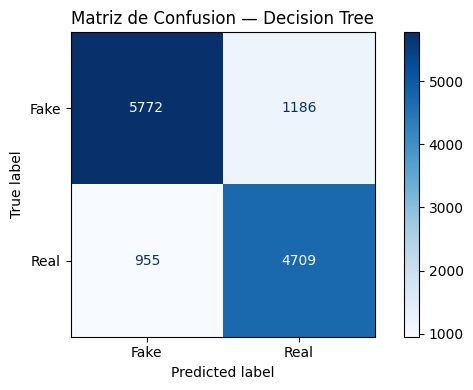

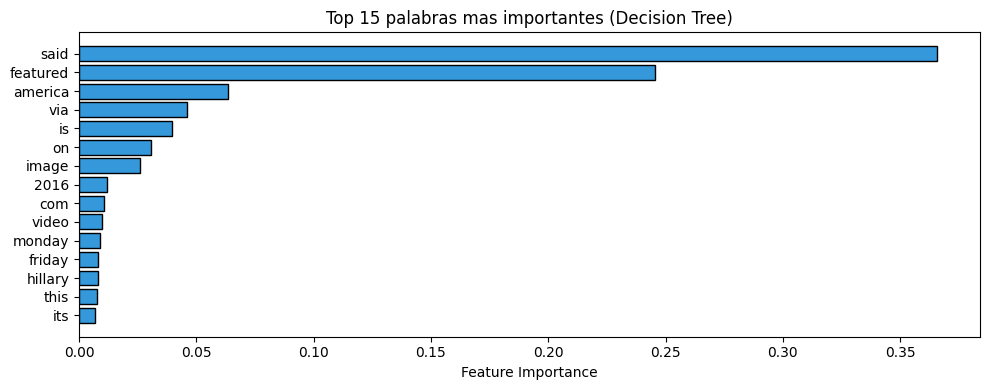

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Analisis detallado con seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, max_features=1000, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Classification Report — Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Fake', 'Real']))
print(f'Profundidad del arbol: {dt.get_depth()}')
print(f'Numero de hojas      : {dt.get_n_leaves()}')

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Fake', 'Real'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusion — Decision Tree')
plt.tight_layout()
plt.show()

# Top 15 palabras mas importantes segun el arbol
importances = dt.feature_importances_
top_idx = np.argsort(importances)[-15:][::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(15), importances[top_idx][::-1], color='#3498db', edgecolor='black')
ax.set_yticks(range(15))
ax.set_yticklabels([words[i] for i in top_idx][::-1])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 palabras mas importantes (Decision Tree)')
plt.tight_layout()
plt.show()


---
## 7. Comparación Final

In [ ]:
import numpy as np

# Tabla resumen
modelos  = ['Logistic Regression', 'SVM (LinearSVC)', 'Naive Bayes', 'Decision Tree']
f1_medias  = [np.mean(f1_lr),  np.mean(f1_svm),  np.mean(f1_nb),  np.mean(f1_dt)]
f1_stds    = [np.std(f1_lr),   np.std(f1_svm),   np.std(f1_nb),   np.std(f1_dt)]
acc_medias = [np.mean(acc_lr), np.mean(acc_svm), np.mean(acc_nb), np.mean(acc_dt)]
acc_stds   = [np.std(acc_lr),  np.std(acc_svm),  np.std(acc_nb),  np.std(acc_dt)]
prec_medias = [np.mean(prec_lr), np.mean(prec_svm), np.mean(prec_nb), np.mean(prec_dt)]
rec_medias  = [np.mean(rec_lr),  np.mean(rec_svm),  np.mean(rec_nb),  np.mean(rec_dt)]

print('=' * 72)
print(f'{"Modelo":<22} {"Accuracy":>14} {"Precision":>14} {"Recall":>14} {"F1":>14}')
print('=' * 72)
for i, modelo in enumerate(modelos):
    print(f'{modelo:<22} '
          f'{acc_medias[i]:.4f}+/-{acc_stds[i]:.4f}  '
          f'{prec_medias[i]:.4f}         '
          f'{rec_medias[i]:.4f}         '
          f'{f1_medias[i]:.4f}+/-{f1_stds[i]:.4f}')
print('=' * 72)

mejor_idx = int(np.argmax(f1_medias))
print(f'\nMejor modelo por F1-Score: {modelos[mejor_idx]}  (F1={f1_medias[mejor_idx]:.4f})')

Modelo                       Accuracy      Precision         Recall             F1
Logistic Regression    0.9498+/-0.0020  0.9461         0.9419         0.9440+/-0.0023
SVM (LinearSVC)        0.9609+/-0.0012  0.9579         0.9549         0.9564+/-0.0014
Naive Bayes            0.8600+/-0.0027  0.8228         0.8769         0.8490+/-0.0029
Decision Tree          0.8314+/-0.0259  0.8160         0.8091         0.8106+/-0.0337

Mejor modelo por F1-Score: SVM (LinearSVC)  (F1=0.9564)


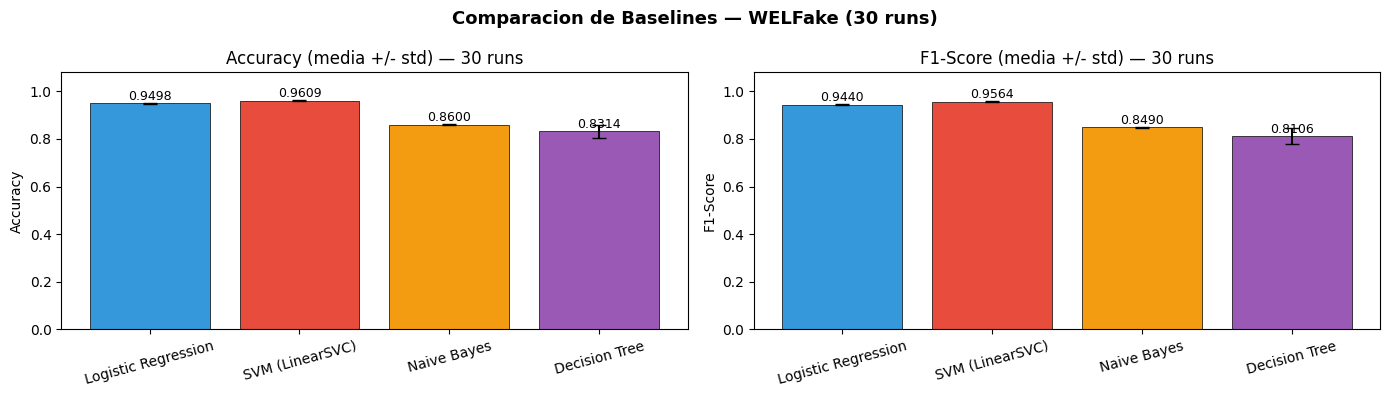

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grafica 1: F1 media con barras de error
colores = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
bars = axes[0].bar(modelos, acc_medias, yerr=acc_stds, capsize=5,
                   color=colores, edgecolor='black', linewidth=0.5)
for bar, media in zip(bars, acc_medias):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{media:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].set_title('Accuracy (media +/- std) — 30 runs')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)

# F1
bars = axes[1].bar(modelos, f1_medias, yerr=f1_stds, capsize=5,
                   color=colores, edgecolor='black', linewidth=0.5)
for bar, media in zip(bars, f1_medias):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                 f'{media:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, 1.08)
axes[1].set_title('F1-Score (media +/- std) — 30 runs')
axes[1].set_ylabel('F1-Score')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparacion de Baselines — WELFake (30 runs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

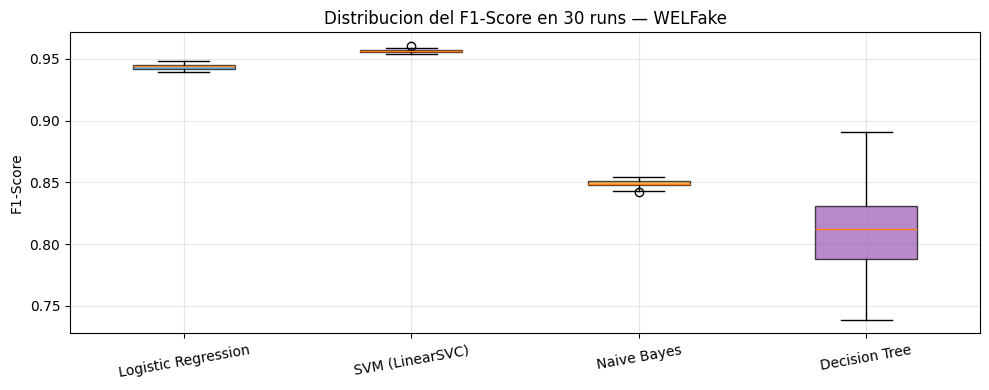


--- Comparacion rapida (media F1) ---
  Logistic Regression   : 0.9440 +/- 0.0023
  SVM (LinearSVC)       : 0.9564 +/- 0.0014
  Naive Bayes           : 0.8490 +/- 0.0029
  Decision Tree         : 0.8106 +/- 0.0337


In [ ]:
import matplotlib.pyplot as plt

# Grafica 2: Boxplots del F1 en las 30 runs
fig, ax = plt.subplots(figsize=(10, 4))

data_box = [f1_lr, f1_svm, f1_nb, f1_dt]
bp = ax.boxplot(data_box, tick_labels=modelos, patch_artist=True)

colores = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1-Score')
ax.set_title('Distribucion del F1-Score en 30 runs — WELFake')
ax.tick_params(axis='x', rotation=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n--- Comparacion rapida (media F1) ---')
for modelo, f1m, f1s in zip(modelos, f1_medias, f1_stds):
    print(f'  {modelo:<22}: {f1m:.4f} +/- {f1s:.4f}')

---
## 8. Análisis

**Ranking final por F1-Score (30 runs):**

| Modelo | Accuracy | F1 | Std |
|--------|----------|----|-----|
| **SVM** | 0.9609 | **0.9564** | ±0.0014 |
| Logistic Regression | 0.9498 | 0.9440 | ±0.0023 |
| Naive Bayes | 0.8600 | 0.8490 | ±0.0029 |
| Decision Tree | 0.8314 | 0.8106 | ±0.0337 |


**SVM (ganador)** — F1=0.9564 con la desviación estándar más baja de todos (±0.0014). Es el modelo más preciso y más estable. Esto confirma lo que dice la teoría: LinearSVC es el modelo más adecuado para clasificación de texto en espacios de alta dimensión como TF-IDF.

**Logistic Regression** — muy cerca del SVM (F1=0.9440), también muy estable (±0.0023). La diferencia de ~1.2 puntos de F1 con el SVM es pequeña pero consistente en los 30 runs, por lo que SVM sí es mejor.

**Naive Bayes** — rendimiento aceptable (F1=0.8490) pero notablemente inferior a los dos modelos lineales. Su precision (0.8228) es considerablemente más baja que su recall (0.8769), lo que significa que tiende a clasificar demasiadas noticias como Fake que en realidad son Reales (más falsos positivos).

**Decision Tree** — el peor modelo con F1=0.8106 y además la desviación estándar más alta por mucho (±0.0337), casi 25 veces más inestable que el SVM. Esto confirma que los árboles son muy sensibles al split de datos en espacios de alta dimensión.